In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

In [14]:
def to_standard_units(x_given):
    return (x_given - np.mean(x_given))/np.std(x_given)

def from_standard_units(x_standard, mean, std):
    return std*x + mean
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 179)
    z = np.random.normal(0,1,179)
    y = r*x + np.sqrt(1-r**2)*z
    return x,y

def make_r_table(r):
   #  np.random.seed(8)
    x,y = make_correlated_data(r)
    x = to_standard_units(x)
    y = to_standard_units(y)
    return Table().with_columns('x',x,'y',y)

def draw_r_table(r):
    my_table = make_r_table(r)
    my_table.scatter('x','y')

def calculate_r_from_table(tbl, x_column_name, y_column_name):
    x_standard = to_standard_units(tbl.column(x_column_name))
    y_standard = to_standard_units(tbl.column(y_column_name))
    return np.average(x_standard * y_standard)

def calculate_r_from_arrays(x_array, y_array):
    x_standard = to_standard_units(x_array)
    y_standard = to_standard_units(y_array)
    return np.average(x_standard * y_standard)                  

def regression_line_in_given_units(x_array, y_array):
    r = calculate_r_from_arrays(x_array, y_array)
    m = r*np.std(y_array)/np.std(x_array)
    b = np.average(y_array) - m*np.average(x_array)
    return m,b
    
def apply_regression_line_to_table(tbl,x_column_name,y_column_name):
    x_array = tbl.column(x_column_name)
    y_array = tbl.column(y_column_name)
    m,b = regression_line_in_given_units(x_array,y_array)
    predictions = m*x_array + b
    return predictions
    
def draw_line(slope=0, intercept=0,x=make_array(-4,4), color = 'r'):
    y = x*slope + intercept
    plots.plot(x,y,color=color)
    
def draw_regression_graph(r):
    tbl = make_r_table(r)
    tbl.scatter('x')
    # draw_line(1)
    draw_line(r,color='g')
    

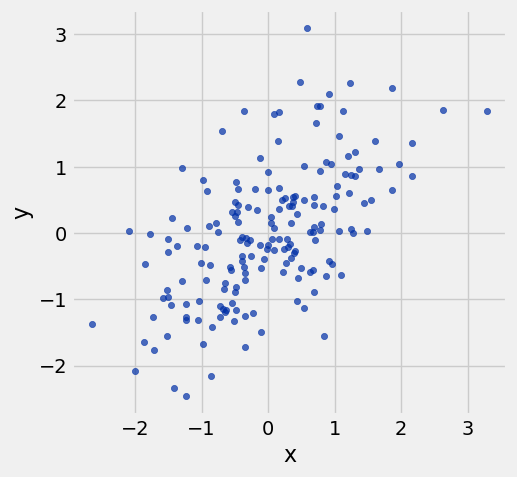

In [10]:
draw_regression_graph(0.5)

In [11]:
my_table = make_r_table(0.7)

In [12]:
calculate_r_from_table(my_table, 'x','y')

0.71818364101464982

In [13]:
calculate_r_from_arrays(my_table.column('x'),my_table.column('y'))

0.71818364101464982

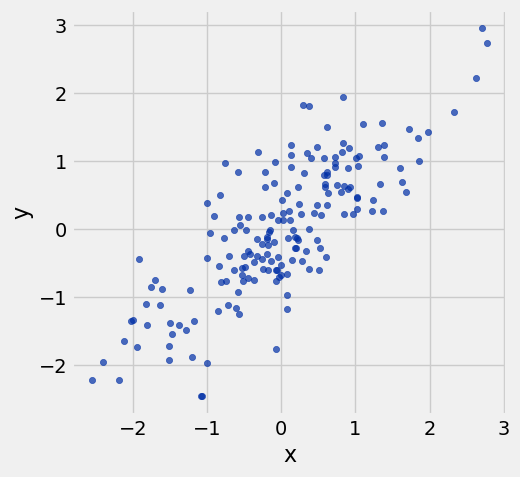

In [15]:
draw_r_table(0.7)

In [17]:
heights = Table.read_table('sons_heights.csv')
heights.show(3)

father,mother,parental average,son
78.5,67,72.75,73.2
75.5,66.5,71,73.5
75,64,69.5,71


In [18]:
predictions = apply_regression_line_to_table(heights,'parental average','son')

In [22]:
parental_averages = heights.column('parental average')
sons = heights.column('son')
my_table = Table().with_columns('parental average',parental_averages, 'actual height',sons, 'predicted height', predictions)

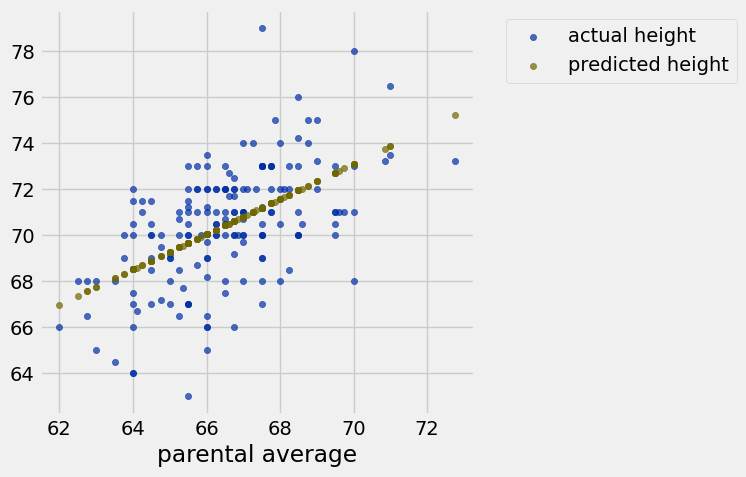

In [23]:
my_table.scatter('parental average')

In [24]:
def predict_height_nn(parental_average):
    sub_table = heights.where('parental average',are.between_or_equal_to(parental_average-1, parental_average+1))
    return np.average(sub_table.column('son'))

In [26]:
predictions_nn = heights.apply(predict_height_nn, 'parental average')

In [27]:
my_table = my_table.with_column('prection nn', predictions_nn)

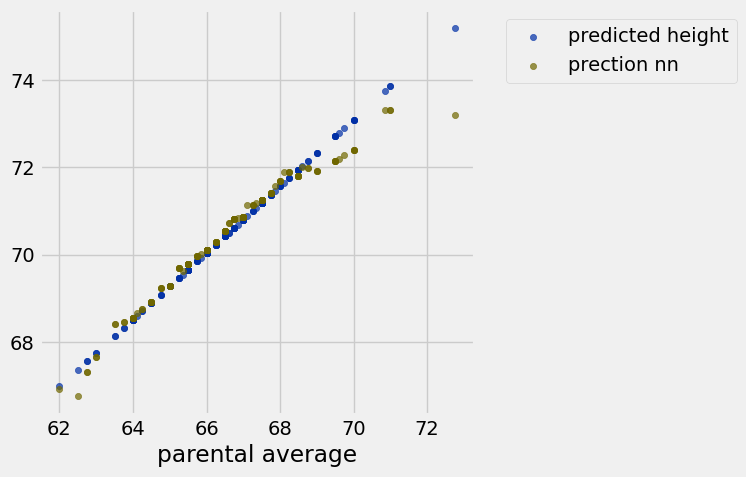

In [30]:
my_table.drop('actual height').scatter('parental average')